In [19]:
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt

gdf = gpd.read_file("C:/Users/isabe/constellation/ligeia_longest_coastline.geojson")
earth_gdf = gpd.read_file("C:/Users/isabe/Downloads/HydroLAKES_polys_v10_shp/HydroLAKES_polys_v10_shp/HydroLAKES_polys_v10.shp")





In [15]:
from shapely.ops import unary_union, linemerge


In [22]:
lake = earth_gdf[earth_gdf["Lake_name"] == "Superior"]

geom = lake.geometry.iloc[0]

coords = geom.exterior.coords  # polygon boundary
coords = list(coords)

x = [c[0] for c in coords]
y = [c[1] for c in coords]

In [25]:
geom = lake.geometry.iloc[0]

coords = geom.exterior.coords  # polygon boundary
coords = list(coords)

e_x = [c[0] for c in coords]
e_y = [c[1] for c in coords]

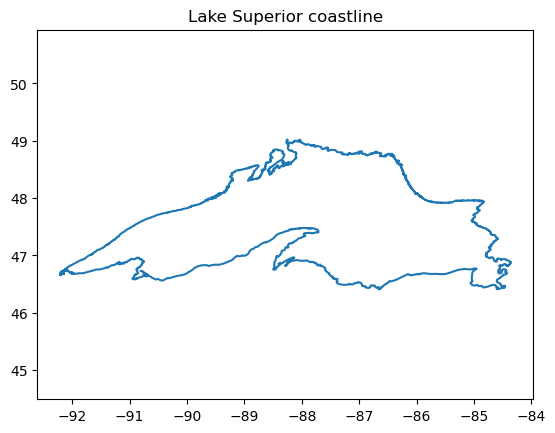

In [24]:
import matplotlib.pyplot as plt

plt.plot(x, y)
plt.axis("equal")
plt.title("Lake Superior coastline")
plt.show()

In [7]:
# collect all coords first
all_x = []
all_y = []


for geom in gdf.geometry:
    coords = np.array(geom.coords)
    all_x.extend(coords[:, 0])
    all_y.extend(coords[:, 1])

x_titan = np.array(all_x)
y_titan = np.array(all_y)


In [5]:
type(geom)

shapely.geometry.linestring.LineString

In [8]:
if x_titan[0] != x_titan[-1] or y_titan[0] != y_titan[-1]:
    x_titan = np.append(x_titan, x_titan[0])
    y_titan = np.append(y_titan, y_titan[0])

In [9]:
def roughness(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    perimeter = np.sum(np.sqrt(dx**2 + dy**2))

    # approximate area (shoelace formula)
    area = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

    return perimeter / np.sqrt(area)

In [26]:
r_titan = roughness(x_titan, y_titan)
r_earth = roughness(e_x, e_y)

In [27]:
print(r_titan)
print(r_earth)

15.178605079955986
11.49364100168829
